# TDA — Amsterdam Centre (canal network) vs Eindhoven North (peri-urban)
Improved visualisations with per-figure interpretation annotations.

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import rasterio
import gudhi
import matplotlib.patches as mpatches
import scipy.ndimage as ndimage
from scipy.spatial import cKDTree

from utils import load_tif, downsample, plot_topological_grids, plot_data_binary, find_critical_points, compute_persistence, annotate_box, pairs_0d

os.makedirs("output", exist_ok=True)

# ── colour palette ────────────────────────────────────────────
AMS_COL   = "#2A7DC9"   # steelblue  (Amsterdam)
EHV_COL   = "#C94F2A"   # burnt orange (Eindhoven)
AMS_LIGHT = "#A8CCE8"
EHV_LIGHT = "#EDBBAA"

CITIES = ["Amsterdam Centre", "Eindhoven North"]
PATHS  = {"Amsterdam Centre": "data/amsterdam_centre_strip.tif",
           "Eindhoven North":  "data/eindhoven_north_strip.tif"}
MAX_SIZE = 700   # cap for critical-point grid (px per side)

### Data Loading
Ensure the `.tif` files are available in the specified directory.

In [4]:
print("Loading data …")
try:
    data = {c: load_tif(PATHS[c]) for c in CITIES}
    ams, ehv = data["Amsterdam Centre"], data["Eindhoven North"]
    print(f"  Amsterdam  shape={ams.shape}  range=[{np.nanmin(ams):.2f}, {np.nanmax(ams):.2f}] m")
    print(f"  Eindhoven  shape={ehv.shape}  range=[{np.nanmin(ehv):.2f}, {np.nanmax(ehv):.2f}] m")
except Exception as e:
    print(f"Error: {e}. Please ensure data files exist in the /data folder.")

Loading data …
  Amsterdam  shape=(25000, 10000)  range=[-10.02, 16.53] m
  Eindhoven  shape=(12500, 20000)  range=[10.40, 35.04] m


### Step 0 — Dataset Statistics

In [5]:
print("=" * 70)
print("DATASET STRUCTURE & STATISTICS")
print("=" * 70)

for name in CITIES:
    d = data[name]
    v = d[~np.isnan(d)]
    
    print(f"\n{name.upper()}")
    print("-" * 70)
    print(f"  Shape (rows, cols):        {d.shape}")
    print(f"  Data type:                 {d.dtype}")
    print(f"  Total pixels:              {d.size:,}")
    print(f"  Missing values (NaN):      {np.isnan(d).sum():,} ({100*np.isnan(d).sum()/d.size:.2f}%)")
    print(f"  Valid data points:         {v.size:,}")
    print(f"\n  Elevation Statistics:")
    print(f"    Min:                     {np.min(v):.3f} m")
    print(f"    Max:                     {np.max(v):.3f} m")
    print(f"    Range:                   {np.max(v) - np.min(v):.3f} m")
    print(f"    Mean:                    {np.mean(v):.3f} m")
    print(f"    Median:                  {np.median(v):.3f} m")
    print(f"    Std Dev:                 {np.std(v):.3f} m")
    print(f"    25th percentile:         {np.percentile(v, 25):.3f} m")
    print(f"    75th percentile:         {np.percentile(v, 75):.3f} m")
    print(f"    IQR:                     {np.percentile(v, 75) - np.percentile(v, 25):.3f} m")
    
    # Local variation analysis
    grad = np.gradient(d)
    slope = np.sqrt(grad[0]**2 + grad[1]**2)
    print(f"\n  Slope Statistics (local variation):")
    print(f"    Mean slope:              {np.nanmean(slope):.4f} m/pixel")
    print(f"    Max slope:               {np.nanmax(slope):.4f} m/pixel")
    print(f"    Std slope:               {np.nanstd(slope):.4f} m/pixel")

DATASET STRUCTURE & STATISTICS

AMSTERDAM CENTRE
----------------------------------------------------------------------
  Shape (rows, cols):        (25000, 10000)
  Data type:                 float64
  Total pixels:              250,000,000
  Missing values (NaN):      99,083,748 (39.63%)
  Valid data points:         150,916,252

  Elevation Statistics:
    Min:                     -10.020 m
    Max:                     16.533 m
    Range:                   26.552 m
    Mean:                    -0.173 m
    Median:                  -0.038 m
    Std Dev:                 2.148 m
    25th percentile:         -1.581 m
    75th percentile:         0.952 m
    IQR:                     2.533 m

  Slope Statistics (local variation):
    Mean slope:              0.0377 m/pixel
    Max slope:               8.4064 m/pixel
    Std slope:               0.0657 m/pixel

EINDHOVEN NORTH
----------------------------------------------------------------------
  Shape (rows, cols):        (12500, 20000)


### Missing Data Visualization


[SUCCESS] Saved unified column visualization to: output/combined_missing_data_mask.png



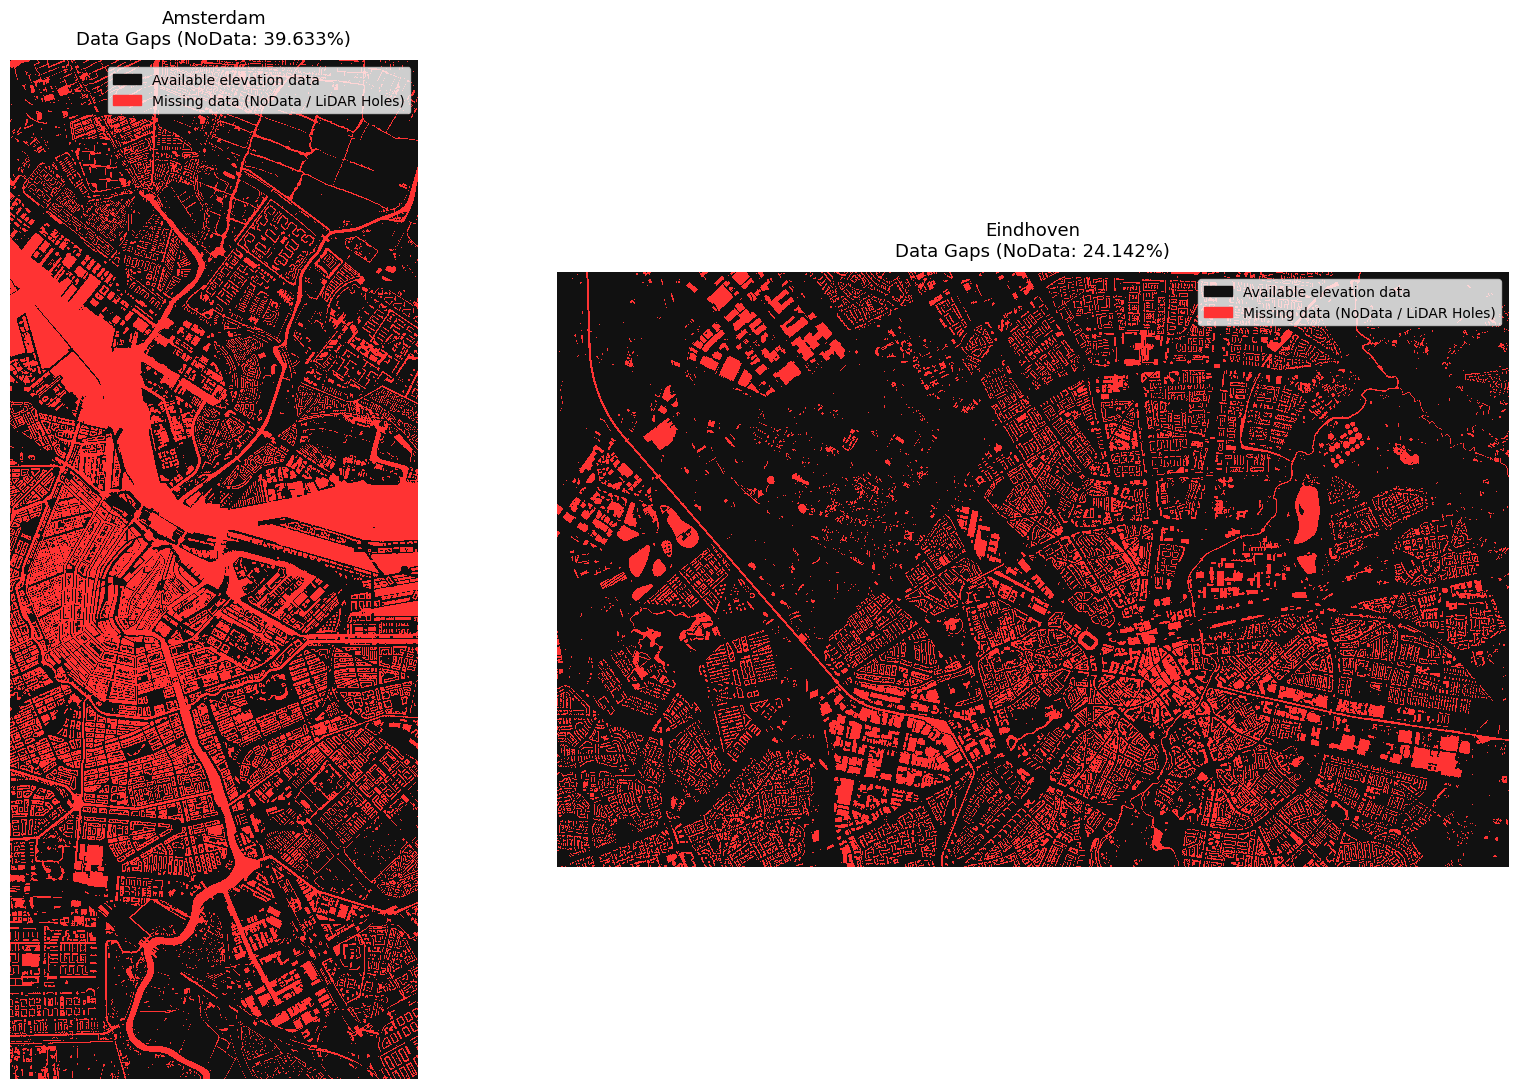

In [72]:
raw_data_dict = {
    "Amsterdam": ams,
    "Eindhoven": ehv
}
plot_data_binary(raw_data_dict, list(raw_data_dict.keys()))

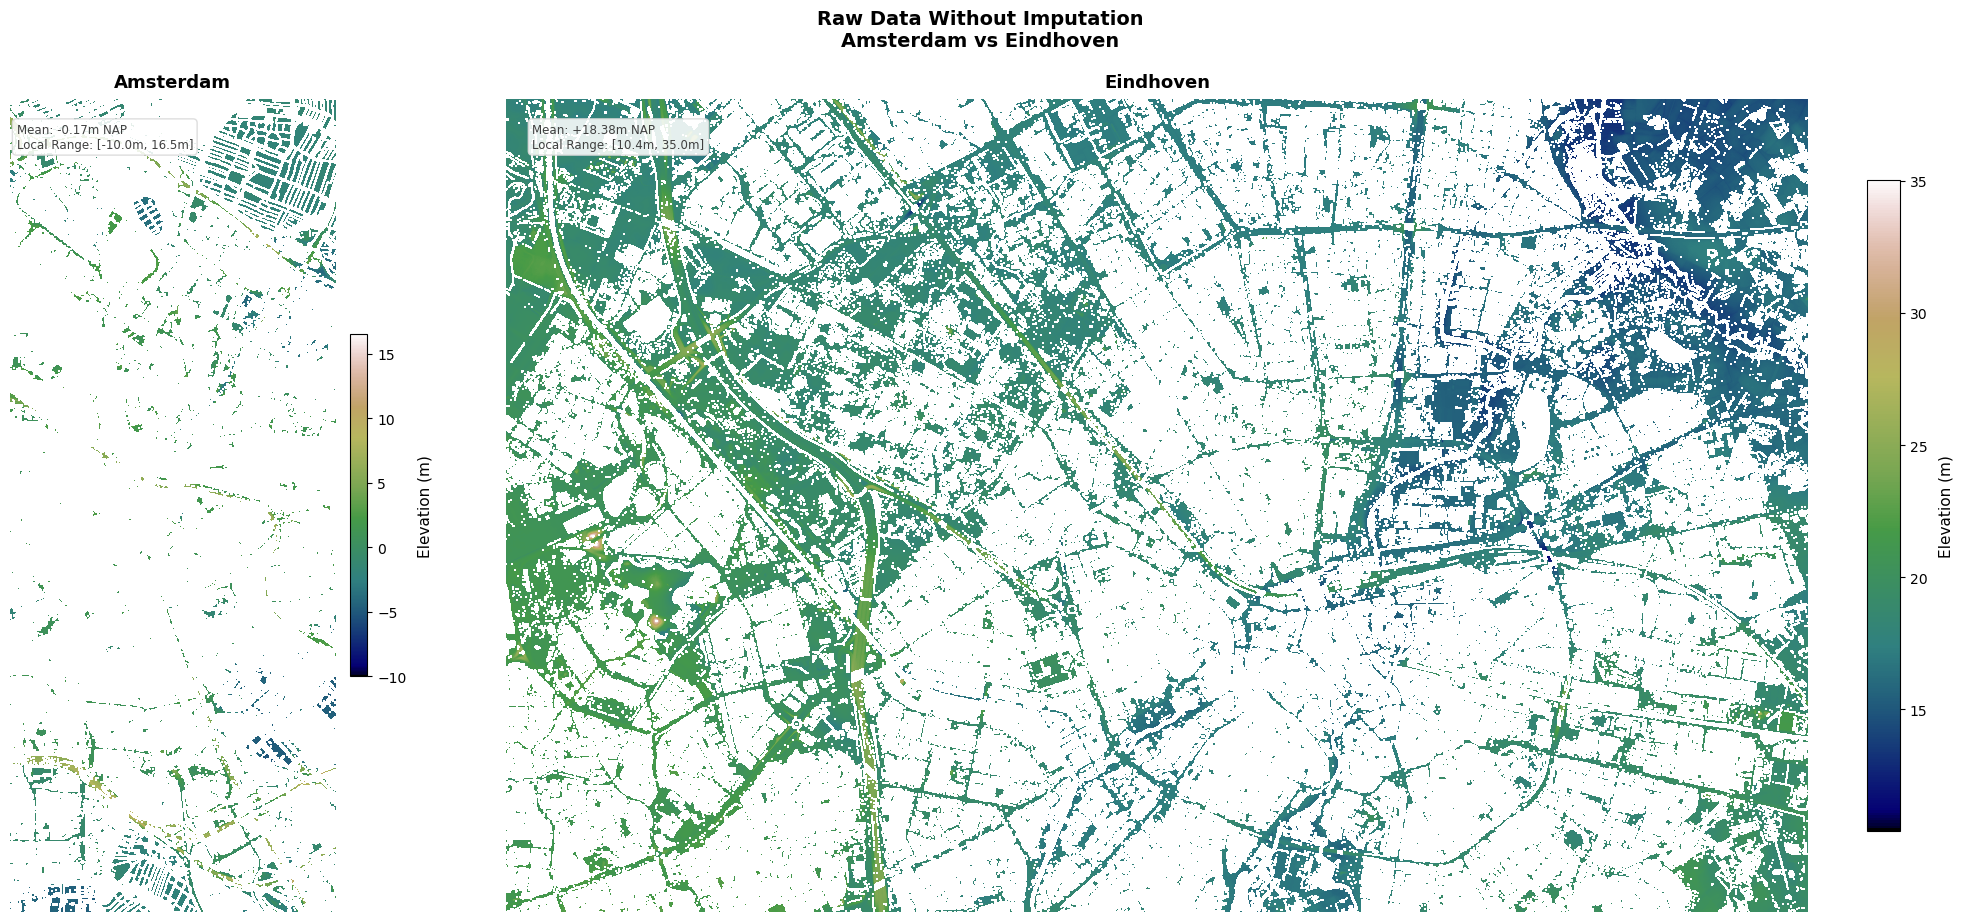

In [73]:
plot_topological_grids(raw_data_dict, step_title="Raw Data Without Imputation", cmap_name="gist_earth")

### Step 1 — Raw Elevation Heatmaps

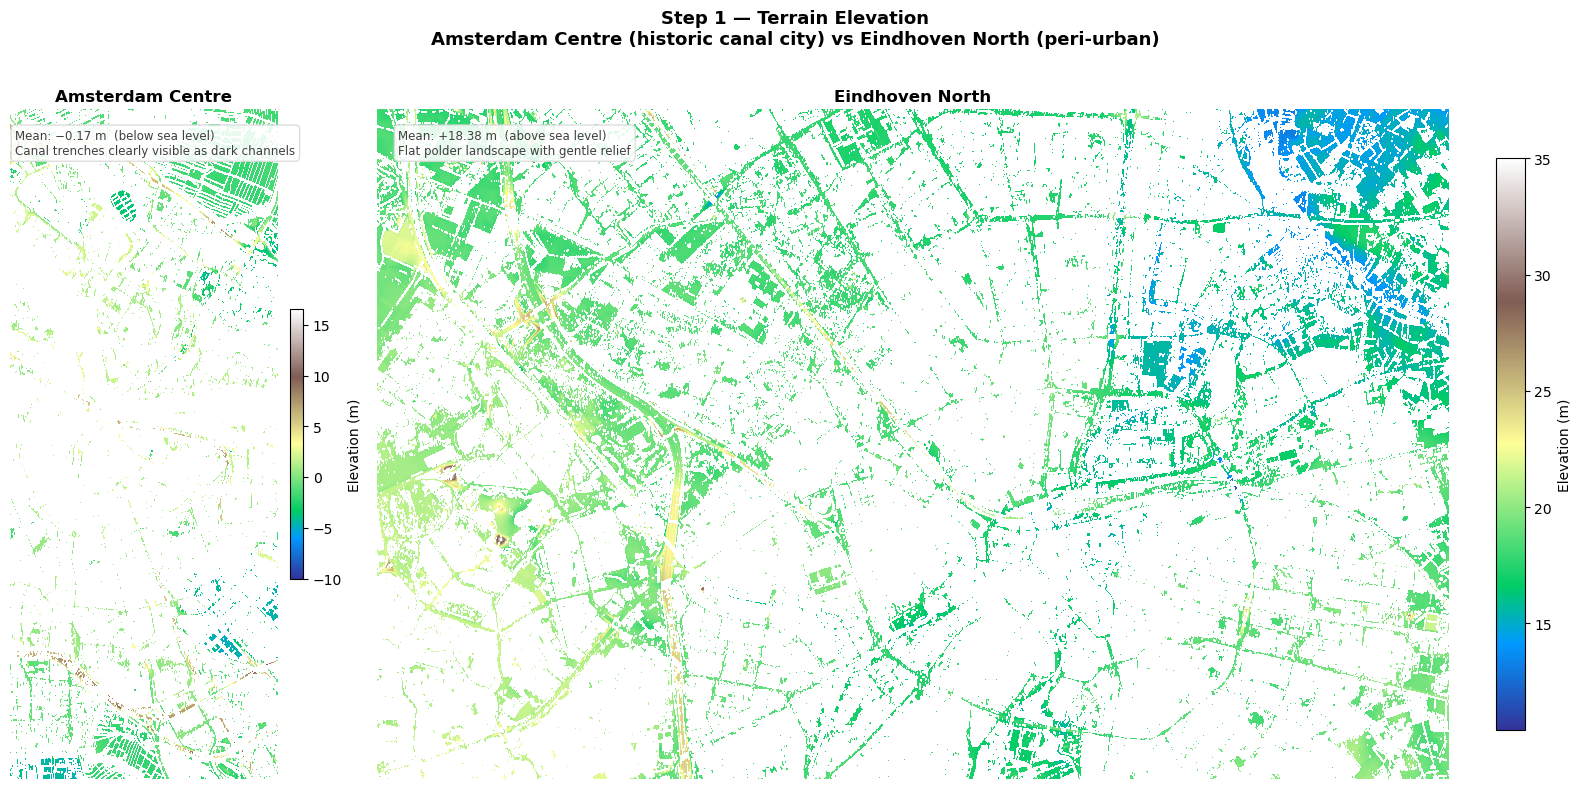

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8),
                         gridspec_kw={"width_ratios":
                                      [ams.shape[1]/ams.shape[0],
                                       ehv.shape[1]/ehv.shape[0]]})
fig.suptitle("Step 1 — Terrain Elevation\n"
             "Amsterdam Centre (historic canal city) vs Eindhoven North (peri-urban)",
             fontsize=13, fontweight="bold", y=1.01)

descs = [
    "Mean: −0.17 m  (below sea level)\nCanal trenches clearly visible as dark channels",
    "Mean: +18.38 m  (above sea level)\nFlat polder landscape with gentle relief"
]
for ax, d, title, desc in zip(axes, [ams, ehv], CITIES, descs):
    im = ax.imshow(d, cmap="terrain", vmin=np.nanmin(d), vmax=np.nanmax(d))
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.axis("off")
    plt.colorbar(im, ax=ax, label="Elevation (m)", fraction=0.046, pad=0.04, shrink=0.8)
    annotate_box(ax, desc)

plt.tight_layout()
plt.show()

### Step 2 — Histograms

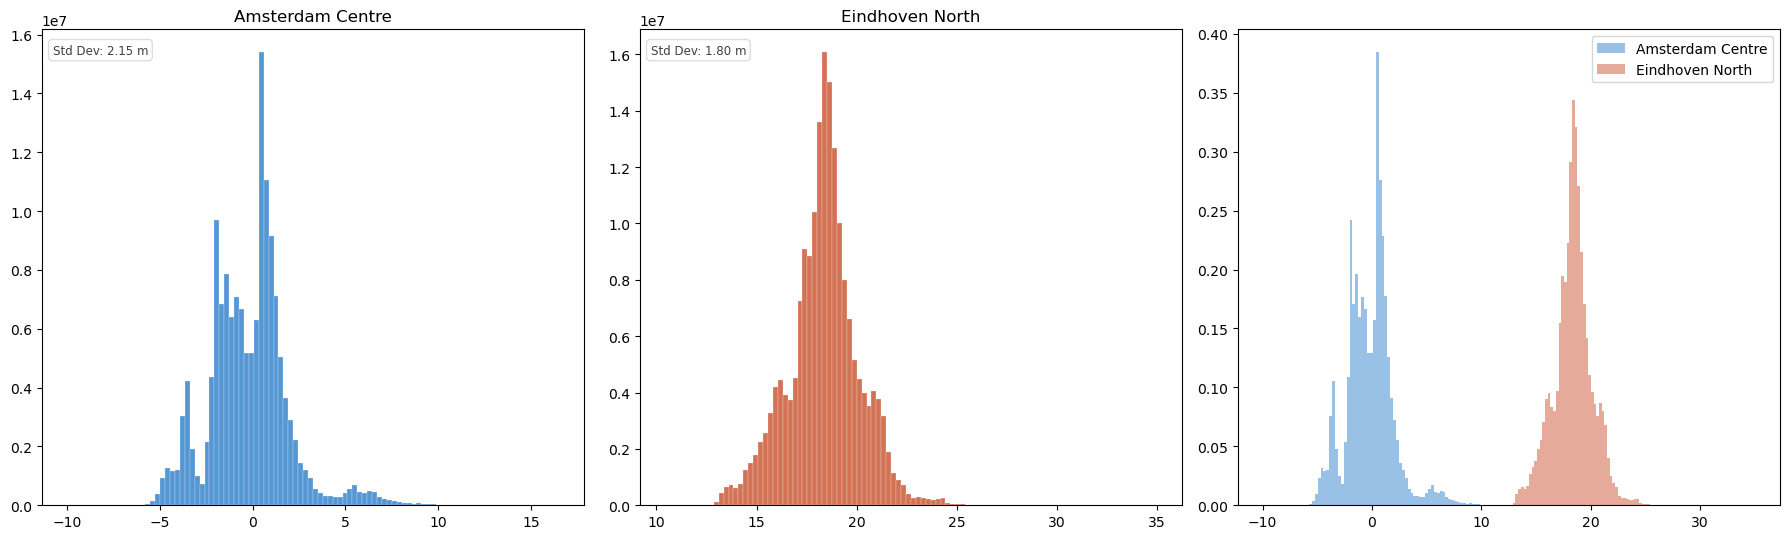

In [9]:
stats = {}
for name, d in data.items():
    v = d[~np.isnan(d)]
    stats[name] = dict(mean=np.mean(v), std=np.std(v), mn=np.min(v), mx=np.max(v))

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for ax, (name, col) in zip(axes[:2], zip(CITIES, [AMS_COL, EHV_COL])):
    v = data[name][~np.isnan(data[name])].flatten()
    ax.hist(v, bins=100, color=col, alpha=0.8, edgecolor="white", linewidth=0.2)
    ax.set_title(name)
    annotate_box(ax, f"Std Dev: {stats[name]['std']:.2f} m")

ax = axes[2]
for name, col in zip(CITIES, [AMS_COL, EHV_COL]):
    v = data[name][~np.isnan(data[name])].flatten()
    ax.hist(v, bins=100, color=col, alpha=0.48, label=name, density=True)
ax.legend()
plt.tight_layout()
plt.show()

### Step 3 — Critical Points

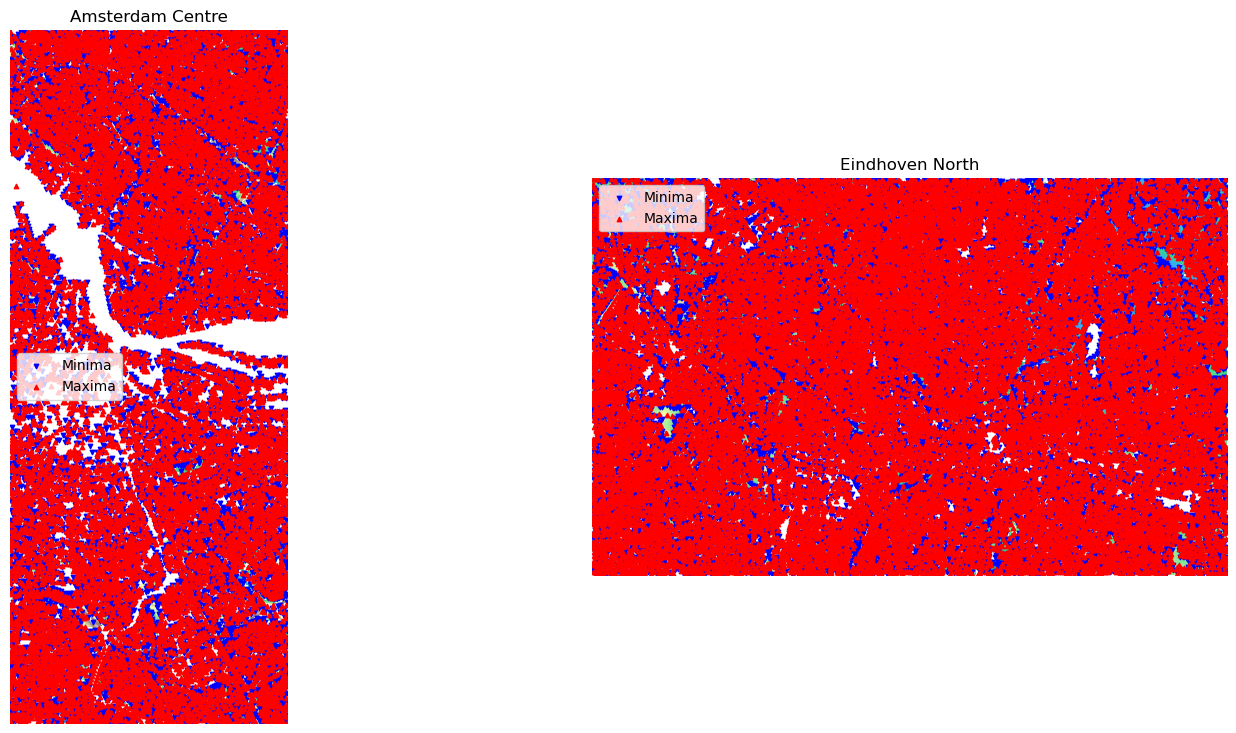

In [10]:
ds = {c: downsample(data[c]) for c in CITIES}
grids = {c: ds[c][0] for c in CITIES}
crit = {c: find_critical_points(grids[c]) for c in CITIES}

fig, axes = plt.subplots(1, 2, figsize=(18, 9))
for ax, c in zip(axes, CITIES):
    g, (mn, mx, sd) = grids[c], crit[c]
    ax.imshow(g, cmap="terrain", alpha=0.8)
    ys, xs = np.where(mn); ax.scatter(xs, ys, c="blue", s=10, marker="v", label="Minima")
    ys, xs = np.where(mx); ax.scatter(xs, ys, c="red", s=10, marker="^", label="Maxima")
    ax.set_title(c); ax.legend(); ax.axis("off")
plt.show()

### Step 4 — Persistence Diagrams

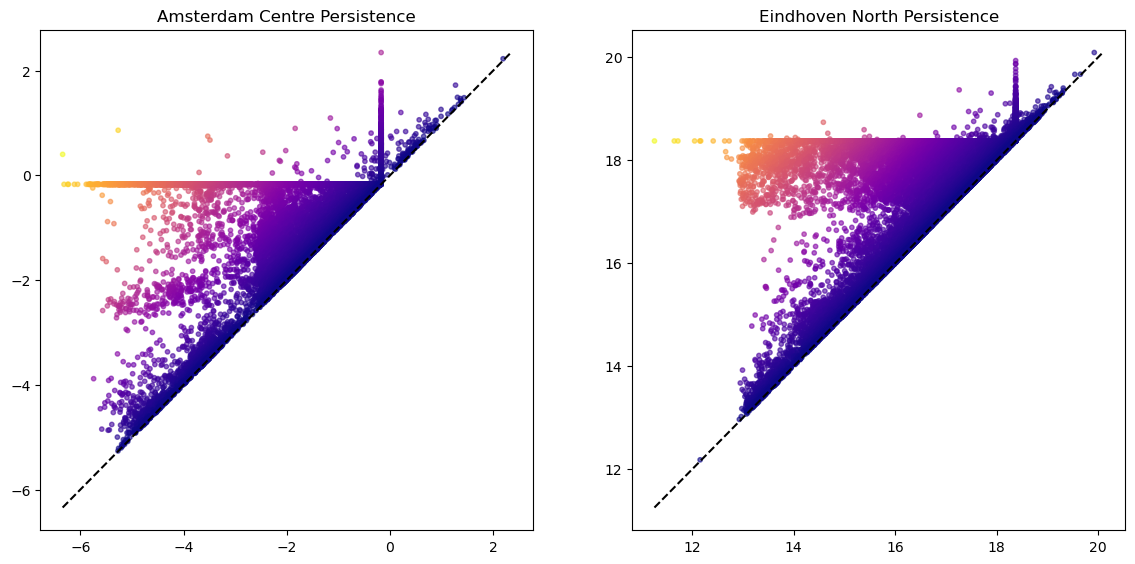

In [11]:
pers = {}
fig, axes = plt.subplots(1, 2, figsize=(14, 6.5))
for ax, c, col in zip(axes, CITIES, [AMS_COL, EHV_COL]):
    pairs, _ = compute_persistence(grids[c])
    p0 = pairs_0d(pairs)
    pers[c] = p0
    births, deaths = np.array([b for b, d in p0]), np.array([d for b, d in p0])
    persist = deaths - births
    sc = ax.scatter(births, deaths, c=persist, cmap="plasma", s=10, alpha=0.6)
    ax.plot([min(births), max(deaths)], [min(births), max(deaths)], "k--")
    ax.set_title(f"{c} Persistence")
plt.show()

### Step 5 — Filtered Minima

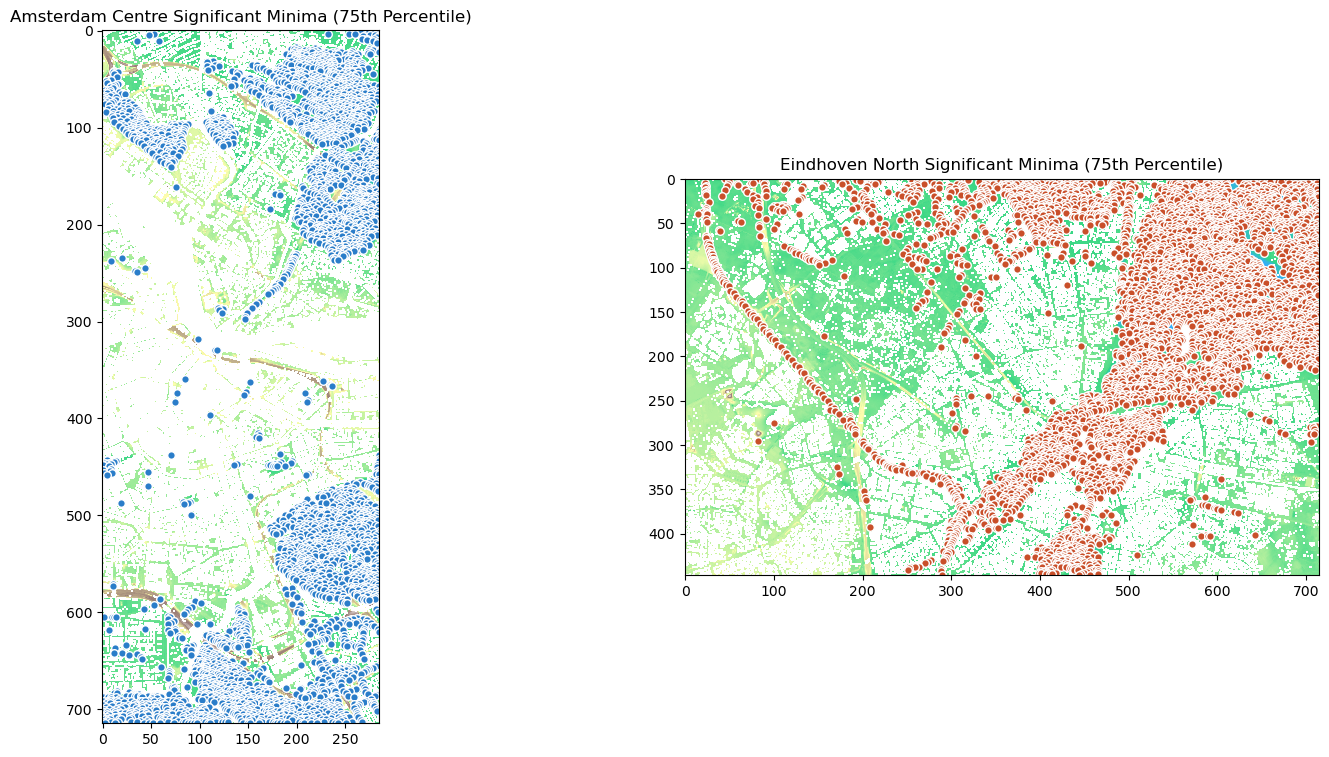

In [12]:
def sig_minima(elev, min_mask, threshold):
    m = np.nanmean(elev)
    sig = np.zeros_like(min_mask)
    ys, xs = np.where(min_mask)
    for y, x in zip(ys, xs):
        if (m - elev[y, x]) >= threshold: sig[y, x] = True
    return sig

fig, axes = plt.subplots(1, 2, figsize=(18, 9))
for ax, c, col in zip(axes, CITIES, [AMS_COL, EHV_COL]):
    g, (mn, _, _) = grids[c], crit[c]
    thresh = np.percentile([d-b for b, d in pers[c]], 75)
    sig = sig_minima(g, mn, thresh)
    ax.imshow(g, cmap="terrain", alpha=0.8)
    ys, xs = np.where(sig); ax.scatter(xs, ys, c=col, s=30, edgecolors="white")
    ax.set_title(f"{c} Significant Minima (75th Percentile)")
plt.show()